# UNIMODAL: clinical close-up

# Notebok for training the models. They are saved and later loaded in another notebook for tests.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import sys

WORK_DIR_ROOT = '/content/drive/MyDrive/datasets/Master/'
sys.path.append(WORK_DIR_ROOT)

from utils import *



DATASET_ROOT = '/content/drive/MyDrive/datasets/Master/datasets_orig'
METADATA_TRAIN_PATH = f"{DATASET_ROOT}/MILK10k_Training_Metadata.csv"
METADATA_TEST_PATH = f"{DATASET_ROOT}/MILK10k_Test_Metadata.csv"
#DATASET_TRAIN_ZIP = f"{DATASET_ROOT}/MILK10k_Training_Input.zip"
DATASET_TRAIN = f"{DATASET_ROOT}/MILK10k_Training_Input/MILK10k_Training_Input/"
DATASET_RESIZED = f"{WORK_DIR_ROOT}/datasets_resized_stratified/"
GT_PATH = f"{DATASET_ROOT}/MILK10k_Training_GroundTruth.csv"


CHECKPOINT_DIR = WORK_DIR_ROOT + 'checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

Mounted at /content/drive


## 1. Load the train and validation datasets, applying transforms, using a custom Dataset class and the stored mao for indices of labels.

### 1.1 Load the custom LABEL_TO_INDEX, and the lessionIds corresponding to Train and Validation.

#### 1.1.1 Prepare a minimal metadata for training and validation by appending the label indices (as saved), and removing the excesive columns

In [ ]:
from utils import LABEL_COLUMNS, LABEL_NAMES
import pandas as pd
import json

df_train_orig = pd.read_csv(METADATA_TRAIN_PATH)

df_gt = pd.read_csv(GT_PATH)

cols = ["lesion_id", "isic_id", "image_type"]

df_train_clinical_minimal = (
    df_train_orig[df_train_orig["image_type"] == "clinical: close-up"]
    [cols]
    .copy()
)

with open(WORK_DIR_ROOT + "/label_to_index.json", "r") as f:
    LABEL_TO_INDEX = json.load(f)

def decode_label_id(row):
    for label_code in LABEL_TO_INDEX:
        if row[label_code] == 1:
            return LABEL_TO_INDEX[label_code]
    raise ValueError("No valid label found in row")

df_gt["label_id"] = df_gt.apply(decode_label_id, axis=1)

df_gt[["lesion_id", "label_id"]].head()

df_train_clinical_minimal = df_train_clinical_minimal.merge(
    df_gt[["lesion_id", "label_id"]],
    on="lesion_id",
    how="left"
)

df_train_clinical_minimal.head()

,lesion_id,isic_id,image_type,label_id
0,IL_0000652,ISIC_8149219,clinical: close-up,1
1,IL_0003176,ISIC_3904045,clinical: close-up,1
2,IL_0004688,ISIC_0791494,clinical: close-up,1
3,IL_0005081,ISIC_5667730,clinical: close-up,9
4,IL_0006177,ISIC_8803389,clinical: close-up,1


#### 1.1.2 Load the lession_ids for train/val/test stratified datasets

In [ ]:
from utils import load_lesion_splits

train_lesions, val_lesions, test_lesions = load_lesion_splits(
    WORK_DIR_ROOT + "/milk10k_lesion_splits.json"
)

print(
    f"Lesions - Train: {len(train_lesions)}, "
    f"Val: {len(val_lesions)}, "
    f"Test: {len(test_lesions)}"
)

# Train
df_train_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(train_lesions)
].reset_index(drop=True)

# Validation
df_val_clinical = df_train_clinical_minimal[
    df_train_clinical_minimal["lesion_id"].isin(val_lesions)
].reset_index(drop=True)



Lesions - Train: 4191, Val: 524, Test: 525


## 1.2 Create data loaders with a custom dataset class

For this purpose, use a custom Dataset called Milk10kDataset_unimodal, which receives a dataframe to read the metadata and labels from, a root directory to read the image files from, a custom transform to apply to the images. It assumes only one image type, so we filter beforehand.

The class is in a separate python file, since there is some issue with using workers in the dataloader if the class is defined in a notebook cell.

We use the custom PyTorch Dataset to load images on demand from the dataset directory based on metadata provided in a dataframe. During training, images are processed using an online data augmentation pipeline implemented via torchvision transforms. Deterministic preprocessing operations (tensor conversion) are combined with stochastic augmentation (TrivialAugmentWide), which applies a randomly sampled transformation each time an image is accessed. As a result, each training epoch iterates once over the full dataset while exposing the model to different augmented versions of the same images across epochs, without increasing the dataset size or storing augmented samples on disk. This way we ensure a more efficient processing and less overfitting.

For validation and testing, only deterministic preprocessing is applied, ensuring a consistent and unbiased evaluation. Data loading is handled via PyTorch DataLoaders, which sample augmented images dynamically at runtime, for improved generalization while maintaining a fixed dataset cardinality.

We use the lesion_id and isic_id to find the next image. We previously resized all images to 224x224. And for the first experiments we load the clinical: close-up images.

#### 1.2.1 Create the data transformers

In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

train_transform = transforms.Compose([
    transforms.TrivialAugmentWide(),
    transforms.ToTensor()])

validation_transform = transforms.Compose([
    transforms.ToTensor()])

#### 1.2.2 Create the data loaders

In [ ]:
from utils import Milk10kDataset_unimodal
from torch.utils.data import DataLoader
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

train_dataset = Milk10kDataset_unimodal(df_train_clinical,
                                        DATASET_RESIZED + "/train",
                                        transform=train_transform)

val_dataset   = Milk10kDataset_unimodal(df_val_clinical,
                                        DATASET_RESIZED + "/validation",
                                        transform=validation_transform)

NUM_WORKERS = os.cpu_count()

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

train_loader, val_loader

Using device: cuda


(<torch.utils.data.dataloader.DataLoader at 0x7a140f1fe000>,
 <torch.utils.data.dataloader.DataLoader at 0x7a140f1fe120>)

In [ ]:
img, label = next(iter(train_loader))

# Note that batch size will now be 1.
print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

ConnectionAbortedError: Caught ConnectionAbortedError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/content/drive/MyDrive/datasets/Master/utils.py", line 39, in __getitem__
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 3513, in open
    fp = builtins.open(filename, "rb")
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ConnectionAbortedError: [Errno 103] Software caused connection abort: '/content/drive/MyDrive/datasets/Master/datasets_resized_stratified/train/IL_4319503/ISIC_8151340.jpg'


## 1 Model train (Backbone ResNet50, 2-stage training: head and full)

2-staged, train custom head with backbone frozen, then unfreaze and train the whole model.

Use smaller learning rate for the second stage training.

### 1.1 Define methods
In a separate pythin class so they're accessable in the test notebook too.

In [ ]:
from ResNet50_1_definitions import *

### 1.2 Use optuna for prameter search (learning rates)


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 13.1 MB/s eta 0:00:00


In [ ]:
import optuna
import torch.nn as nn

def objective(trial):
    lr_head = trial.suggest_loguniform("lr_head", 1e-4, 1e-3)
    lr_full = trial.suggest_loguniform("lr_full", 1e-5, 1e-4)

    model = ResNet50Classifier(num_classes=11).to(device)
    criterion = nn.CrossEntropyLoss()

    # STAGE 1: HEAD ONLY
    freeze_backbone(model)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr_head
    )

    train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        device,
        epochs=10,   # short for Optuna
        patience=3
    )

    # STAGE 2: FULL MODEL
    unfreeze_backbone(model)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr_full
    )

    train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        device,
        epochs=10,   # also short
        patience=3
    )

    # Final evaluation
    _, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    return val_acc

############# Run the study:
if False:
  study = optuna.create_study(
      direction="maximize"  # because we return val_acc
  )

  study.optimize(
      objective,
      n_trials=4,
      timeout=None          # optional
  )

  print("Best validation accuracy:", study.best_value)
  print("Best hyperparameters:", study.best_params)

In [ ]:
# Best validation accuracy: 0.6603053435114504
# Best hyperparameters: {'lr_head': 0.0009966109292669566, 'lr_full': 7.342367779515795e-05}

### 1.3 Train the model with the best learning rates from optuna

In [ ]:
# check if the study metadata is not defined, if not use the last know info:
try:
  study.best_params
except:
  study = None
  #ignore?

if study is None:
  best_lr_head = 0.0009966109292669566
  best_lr_full = 7.342367779515795e-05
else:
  best_lr_head = study.best_params["lr_head"]
  best_lr_full = best_lr_head * 0.1

model = ResNet50Classifier(num_classes=11).to(device)
criterion = nn.CrossEntropyLoss()

# Stage 1
freeze_backbone(model)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=best_lr_head
)

train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=30,
    patience=7,
    save_path=CHECKPOINT_DIR+"/RESNET_1_best_stage1.pt"
)

# Stage 2
unfreeze_backbone(model)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=best_lr_full
)

train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50,
    patience=7,
    save_path=CHECKPOINT_DIR+"/RESNET_1_best_stage2.pt"
)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 81.7MB/s]


Epoch [1/30] | Train Loss: 1.5093 | Val Loss: 1.2484 | Val Acc: 0.5821
Best model saved
Epoch [2/30] | Train Loss: 1.2877 | Val Loss: 1.2043 | Val Acc: 0.5859
Best model saved
Epoch [3/30] | Train Loss: 1.2500 | Val Loss: 1.1852 | Val Acc: 0.5973
Best model saved
Epoch [4/30] | Train Loss: 1.2266 | Val Loss: 1.1771 | Val Acc: 0.5802
Best model saved
Epoch [5/30] | Train Loss: 1.2102 | Val Loss: 1.1915 | Val Acc: 0.5954
Epoch [6/30] | Train Loss: 1.2007 | Val Loss: 1.1765 | Val Acc: 0.5973
Best model saved
Epoch [7/30] | Train Loss: 1.1815 | Val Loss: 1.1336 | Val Acc: 0.5992
Best model saved
Epoch [8/30] | Train Loss: 1.1790 | Val Loss: 1.1457 | Val Acc: 0.6164
Epoch [9/30] | Train Loss: 1.1708 | Val Loss: 1.1736 | Val Acc: 0.6164
Epoch [10/30] | Train Loss: 1.1701 | Val Loss: 1.1499 | Val Acc: 0.6088
Epoch [11/30] | Train Loss: 1.1331 | Val Loss: 1.1479 | Val Acc: 0.6031
Epoch [12/30] | Train Loss: 1.1401 | Val Loss: 1.1506 | Val Acc: 0.6145
Epoch [13/30] | Train Loss: 1.1381 | Val Lo

ResNet50Classifier(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential

## 2 Model train (Backbone ViT_b_16, 2-stage training: head and full)

### 2.1 Model definition

In [ ]:
from ViTClassifier_1_definitions import *

### 2.2 Search for best learning rate with Optuna

In [ ]:
import optuna

def objective(trial):
    lr_head = trial.suggest_float("lr_head", 1e-4, 1e-3, log=True)
    lr_full = trial.suggest_float("lr_full", 1e-5, 1e-4, log=True)

    model = ViTClassifier(num_classes=11).to(device)
    criterion = nn.CrossEntropyLoss()

    # Stage 1: HEAD only
    freeze_backbone(model)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                                  lr=lr_head)
    train_model(model,
                train_loader,
                val_loader,
                criterion,
                optimizer,
                device,
                epochs=10,
                patience=3,
                save_path=f"{CHECKPOINT_DIR}/vit_1_stage1.pt")

    # Stage 2: FULL model
    unfreeze_backbone(model)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr_full)
    train_model(model,
                train_loader,
                val_loader,
                criterion,
                optimizer,
                device,
                epochs=10,
                patience=3,
                save_path=f"{CHECKPOINT_DIR}/vit_1_stage2.pt")

    _, val_acc = evaluate(model, val_loader, criterion, device)
    return val_acc

# Run Optuna
if True:
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=4)  # short for baseline
    print("Best validation accuracy:", study.best_value)
    print("Best hyperparameters:", study.best_params)

[I 2026-02-19 09:22:08,792] A new study created in memory with name: no-name-c22cfc0c-2a88-4761-9d23-611407cccb17


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 142MB/s]


Epoch [1/10] | Train Loss: 1.6439 | Val Loss: 1.2770 | Val Acc: 0.6050
Best model saved
Epoch [2/10] | Train Loss: 1.2961 | Val Loss: 1.1648 | Val Acc: 0.6279
Best model saved
Epoch [3/10] | Train Loss: 1.2345 | Val Loss: 1.1389 | Val Acc: 0.6298
Best model saved
Epoch [4/10] | Train Loss: 1.2080 | Val Loss: 1.1063 | Val Acc: 0.6260
Best model saved
Epoch [5/10] | Train Loss: 1.1557 | Val Loss: 1.1007 | Val Acc: 0.6221
Best model saved
Epoch [6/10] | Train Loss: 1.1499 | Val Loss: 1.0919 | Val Acc: 0.6336
Best model saved
Epoch [7/10] | Train Loss: 1.1410 | Val Loss: 1.0831 | Val Acc: 0.6336
Best model saved
Epoch [8/10] | Train Loss: 1.1200 | Val Loss: 1.0705 | Val Acc: 0.6489
Best model saved
Epoch [9/10] | Train Loss: 1.0923 | Val Loss: 1.0647 | Val Acc: 0.6412
Best model saved
Epoch [10/10] | Train Loss: 1.0965 | Val Loss: 1.0518 | Val Acc: 0.6546
Best model saved
Epoch [1/10] | Train Loss: 1.0612 | Val Loss: 1.0208 | Val Acc: 0.6622
Best model saved
Epoch [2/10] | Train Loss: 0.99

[I 2026-02-19 10:03:29,409] Trial 0 finished with value: 0.683206106870229 and parameters: {'lr_head': 0.0004615619914925977, 'lr_full': 1.1526026851977796e-05}. Best is trial 0 with value: 0.683206106870229.


Epoch [1/10] | Train Loss: 1.8493 | Val Loss: 1.4603 | Val Acc: 0.5782
Best model saved
Epoch [2/10] | Train Loss: 1.4110 | Val Loss: 1.2718 | Val Acc: 0.6126
Best model saved
Epoch [3/10] | Train Loss: 1.3101 | Val Loss: 1.2059 | Val Acc: 0.6088
Best model saved
Epoch [4/10] | Train Loss: 1.2543 | Val Loss: 1.1616 | Val Acc: 0.6221
Best model saved
Epoch [5/10] | Train Loss: 1.2224 | Val Loss: 1.1439 | Val Acc: 0.6088
Best model saved
Epoch [6/10] | Train Loss: 1.2024 | Val Loss: 1.1164 | Val Acc: 0.6202
Best model saved
Epoch [7/10] | Train Loss: 1.1627 | Val Loss: 1.1122 | Val Acc: 0.6279
Best model saved
Epoch [8/10] | Train Loss: 1.1471 | Val Loss: 1.0967 | Val Acc: 0.6164
Best model saved
Epoch [9/10] | Train Loss: 1.1382 | Val Loss: 1.0887 | Val Acc: 0.6336
Best model saved
Epoch [10/10] | Train Loss: 1.1268 | Val Loss: 1.0793 | Val Acc: 0.6393
Best model saved
Epoch [1/10] | Train Loss: 1.0898 | Val Loss: 1.0519 | Val Acc: 0.6393
Best model saved
Epoch [2/10] | Train Loss: 1.03

[I 2026-02-19 10:41:59,101] Trial 1 finished with value: 0.6717557251908397 and parameters: {'lr_head': 0.00019856493293526203, 'lr_full': 1.0626356235870238e-05}. Best is trial 0 with value: 0.683206106870229.


Epoch [1/10] | Train Loss: 1.5472 | Val Loss: 1.2237 | Val Acc: 0.5954
Best model saved
Epoch [2/10] | Train Loss: 1.2763 | Val Loss: 1.1341 | Val Acc: 0.6202
Best model saved
Epoch [3/10] | Train Loss: 1.2232 | Val Loss: 1.1175 | Val Acc: 0.6240
Best model saved
Epoch [4/10] | Train Loss: 1.1935 | Val Loss: 1.1136 | Val Acc: 0.6298
Best model saved
Epoch [5/10] | Train Loss: 1.1589 | Val Loss: 1.0879 | Val Acc: 0.6145
Best model saved
Epoch [6/10] | Train Loss: 1.1421 | Val Loss: 1.0704 | Val Acc: 0.6355
Best model saved
Epoch [7/10] | Train Loss: 1.1285 | Val Loss: 1.0833 | Val Acc: 0.6279
Epoch [8/10] | Train Loss: 1.1149 | Val Loss: 1.0972 | Val Acc: 0.6221
Epoch [9/10] | Train Loss: 1.1051 | Val Loss: 1.0530 | Val Acc: 0.6298
Best model saved
Epoch [10/10] | Train Loss: 1.0906 | Val Loss: 1.0548 | Val Acc: 0.6336
Epoch [1/10] | Train Loss: 1.0661 | Val Loss: 1.1045 | Val Acc: 0.6412
Best model saved
Epoch [2/10] | Train Loss: 0.9971 | Val Loss: 0.9970 | Val Acc: 0.6565
Best model 

[I 2026-02-19 11:14:43,306] Trial 2 finished with value: 0.6507633587786259 and parameters: {'lr_head': 0.0006118724923072575, 'lr_full': 1.840754839817741e-05}. Best is trial 0 with value: 0.683206106870229.


Epoch [1/10] | Train Loss: 1.4930 | Val Loss: 1.2087 | Val Acc: 0.6050
Best model saved


[I 2026-02-19 10:03:29,409] Trial 0 finished with value: 0.683206106870229 and parameters: {'lr_head': 0.0004615619914925977, 'lr_full': 1.1526026851977796e-05}. Best is trial 0 with value: 0.683206106870229.


[I 2026-02-19 10:41:59,101] Trial 1 finished with value: 0.6717557251908397 and parameters: {'lr_head': 0.00019856493293526203, 'lr_full': 1.0626356235870238e-05}. Best is trial 0 with value: 0.683206106870229.


[I 2026-02-19 11:14:43,306] Trial 2 finished with value: 0.6507633587786259 and parameters: {'lr_head': 0.0006118724923072575, 'lr_full': 1.840754839817741e-05}. Best is trial 0 with value: 0.683206106870229.


### 2.3 Train model with best learning rate found by Optuna

In [ ]:
try:
  study.best_params
except:
  study = None
  #ignore?

if study is None:
  best_lr_head = 0.0004615619914925977
  best_lr_full = 1.1526026851977796e-05
else:
  best_lr_head = study.best_params["lr_head"]
  best_lr_full = best_lr_head * 0.1
# Initialize model and criterion
model = ViTClassifier(num_classes=11).to(device)
criterion = nn.CrossEntropyLoss()

# Stage 1: Train HEAD only
freeze_backbone(model)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=best_lr_head
)

model = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=30,   # full training for head
    patience=7,
    save_path=f"{CHECKPOINT_DIR}/vit_1_best_stage1.pt"
)

# Stage 2: Train FULL model
unfreeze_backbone(model)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=best_lr_full
)

model = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50,   # full training for full model
    patience=7,
    save_path=f"{CHECKPOINT_DIR}/vit_1_best_stage2.pt"
)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:03<00:00, 100MB/s]


Epoch [1/30] | Train Loss: 1.5965 | Val Loss: 1.2406 | Val Acc: 0.6069
Best model saved
Epoch [2/30] | Train Loss: 1.2973 | Val Loss: 1.1556 | Val Acc: 0.6202
Best model saved
Epoch [3/30] | Train Loss: 1.2312 | Val Loss: 1.1105 | Val Acc: 0.6393
Best model saved
Epoch [4/30] | Train Loss: 1.1939 | Val Loss: 1.1024 | Val Acc: 0.6298
Best model saved
Epoch [5/30] | Train Loss: 1.1615 | Val Loss: 1.1008 | Val Acc: 0.6240
Best model saved
Epoch [6/30] | Train Loss: 1.1473 | Val Loss: 1.0854 | Val Acc: 0.6317
Best model saved
Epoch [7/30] | Train Loss: 1.1336 | Val Loss: 1.0669 | Val Acc: 0.6374
Best model saved
Epoch [8/30] | Train Loss: 1.1123 | Val Loss: 1.0683 | Val Acc: 0.6336
Epoch [9/30] | Train Loss: 1.1233 | Val Loss: 1.0679 | Val Acc: 0.6317
Epoch [10/30] | Train Loss: 1.0813 | Val Loss: 1.0654 | Val Acc: 0.6317
Best model saved
Epoch [11/30] | Train Loss: 1.0864 | Val Loss: 1.0550 | Val Acc: 0.6279
Best model saved
Epoch [12/30] | Train Loss: 1.0806 | Val Loss: 1.0743 | Val Acc:

## 3. ViT with CLS and Patch Pooling (ViT-CLS+Mean)
Again, two stage training - head and full body. Parameter search for batch size and learnng rate done with Optuna.

** Best hyperparameters: **

$ lr_{head}: 0.00035950484601540223 $

$lr_{full}: 2.271080330783799e-05 $

$ batchsize: 8 $

This work employs a Vision Transformer (ViT-B/16)–based image classification model initialized with ImageNet-1K pretrained weights. The proposed architecture modifies the standard ViT classification head by combining information from both the CLS token and the aggregated patch tokens, aiming to obtain a more robust global image representation for medical image classification.

The backbone of the model is the ViT-B/16 architecture, which splits the input image into non-overlapping 16×16 patches, embeds them into a latent space, and processes the resulting token sequence using a stack of Transformer encoder layers with multi-head self-attention.

### 3.1 Model definition

In [ ]:
import torch
import torch.nn as nn
from torchvision import models
import copy
from sklearn.metrics import accuracy_score

class ViTClassifierCLSPool(nn.Module):
    """
    Combines CLS token + mean patch pooling
    More robust feature representation
    """
    def __init__(self, num_classes=11, dropout=0.5):
        super().__init__()

        self.vit = models.vit_b_16(
            weights=models.ViT_B_16_Weights.IMAGENET1K_V1
        )

        hidden_dim = self.vit.hidden_dim

        # Remove original head
        self.vit.heads = nn.Identity()

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim * 2),
            nn.Linear(hidden_dim * 2, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        n = x.shape[0]

        # ViT forward until encoder output
        x = self.vit._process_input(x)
        cls_token = self.vit.class_token.expand(n, -1, -1)
        x = torch.cat((cls_token, x), dim=1)
        x = self.vit.encoder(x)

        # CLS token
        cls_feat = x[:, 0]

        # Mean pooling over patch tokens
        patch_feat = x[:, 1:].mean(dim=1)

        features = torch.cat([cls_feat, patch_feat], dim=1)
        return self.classifier(features)

# Freeze / Unfreeze helpers
def freeze_backbone(model):
    for param in model.vit.parameters():
        param.requires_grad = False

    for param in model.classifier.parameters():
        param.requires_grad = True

def unfreeze_backbone(model):
    for param in model.parameters():
        param.requires_grad = True

# Training / Evaluation
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    preds, targets = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        preds.append(outputs.argmax(dim=1).cpu())
        targets.append(labels.cpu())
    preds = torch.cat(preds)
    targets = torch.cat(targets)
    acc = accuracy_score(targets, preds)
    return total_loss / len(loader.dataset), acc

def train_model(model, train_loader, val_loader, criterion, optimizer, device,
                epochs=50, patience=10, save_path="best_model.pt"):
    best_val_loss = float("inf")
    patience_counter = 0
    best_weights = copy.deepcopy(model.state_dict())

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(1, epochs+1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        # store values
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch [{epoch}/{epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            # if save_path is not None:
            #   torch.save(model.state_dict(), save_path)
            best_checkpoint = {
                "epoch": epoch,
                "model_state": copy.deepcopy(model.state_dict()),
                "optimizer_state": optimizer.state_dict(),
                "history": copy.deepcopy(history),
                "best_val_loss": best_val_loss
            }

            if save_path is not None:
                if CHECKPOINT_DIR not in save_path:
                  if '/' not in save_path:
                    save_path = CHECKPOINT_DIR + '/' + save_path
                  else:
                    save_path = CHECKPOINT_DIR + save_path

                torch.save(best_checkpoint, save_path)
                print("Best model + history saved")

            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered")
            break

    model.load_state_dict(best_weights)
    return model, history

### 3.2 Optuna search for learning rate and batch size

In [ ]:
import optuna
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

def objective(trial):
    # Hyperparameters
    lr_head = trial.suggest_float("lr_head", 1e-4, 1e-3, log=True)
    lr_full = trial.suggest_float("lr_full", 1e-5, 1e-4, log=True)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])

    # Rebuild dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    # Model
    model = ViTClassifierCLSPool(num_classes=11).to(device)
    criterion = nn.CrossEntropyLoss()

    # Stage 1: classifier only
    freeze_backbone(model)

    optimizer = torch.optim.AdamW(
        model.classifier.parameters(),
        lr=lr_head
    )

    train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        device,
        epochs=10,
        patience=3,
        save_path=None
    )

    # Stage 2: full fine-tuning
    unfreeze_backbone(model)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr_full
    )

    train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        device,
        epochs=10,
        patience=3,
        save_path=None
    )

    _, val_acc = evaluate(model, val_loader, criterion, device)
    return val_acc


if True:
  study = optuna.create_study(direction="maximize")
  study.optimize(objective, n_trials=5)

  print("Best validation accuracy:", study.best_value)
  print("Best hyperparameters:", study.best_params)

[I 2026-02-25 12:19:38,254] A new study created in memory with name: no-name-f62bfddb-4efc-48a3-bd11-8beacf3764a9


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 199MB/s]


Epoch [1/10] | Train Loss: 1.3820 | Val Loss: 1.1834 | Val Acc: 0.5992
Best model saved
Epoch [2/10] | Train Loss: 1.2276 | Val Loss: 1.1570 | Val Acc: 0.6011
Best model saved
Epoch [3/10] | Train Loss: 1.1801 | Val Loss: 1.1286 | Val Acc: 0.6183
Best model saved
Epoch [4/10] | Train Loss: 1.1581 | Val Loss: 1.1016 | Val Acc: 0.6145
Best model saved
Epoch [5/10] | Train Loss: 1.1496 | Val Loss: 1.0824 | Val Acc: 0.6183
Best model saved
Epoch [6/10] | Train Loss: 1.1155 | Val Loss: 1.0721 | Val Acc: 0.6240
Best model saved
Epoch [7/10] | Train Loss: 1.1047 | Val Loss: 1.0723 | Val Acc: 0.6240
Epoch [8/10] | Train Loss: 1.1029 | Val Loss: 1.0832 | Val Acc: 0.6260
Epoch [9/10] | Train Loss: 1.0788 | Val Loss: 1.0852 | Val Acc: 0.6279
Early stopping triggered
Epoch [1/10] | Train Loss: 1.1475 | Val Loss: 1.1258 | Val Acc: 0.6279
Best model saved
Epoch [2/10] | Train Loss: 1.0410 | Val Loss: 1.0712 | Val Acc: 0.6279
Best model saved
Epoch [3/10] | Train Loss: 0.9744 | Val Loss: 1.0962 | Val

[I 2026-02-25 13:20:41,378] Trial 0 finished with value: 0.6755725190839694 and parameters: {'lr_head': 0.00035950484601540223, 'lr_full': 2.271080330783799e-05, 'batch_size': 8}. Best is trial 0 with value: 0.6755725190839694.


...

Epoch [1/10] | Train Loss: 1.3793 | Val Loss: 1.1894 | Val Acc: 0.6126
Best model saved
Epoch [2/10] | Train Loss: 1.2228 | Val Loss: 1.1382 | Val Acc: 0.6221
Best model saved
Epoch [3/10] | Train Loss: 1.1816 | Val Loss: 1.1151 | Val Acc: 0.6031
Best model saved
Epoch [4/10] | Train Loss: 1.1412 | Val Loss: 1.1698 | Val Acc: 0.6164
Epoch [5/10] | Train Loss: 1.1215 | Val Loss: 1.0894 | Val Acc: 0.6221
Best model saved
Epoch [6/10] | Train Loss: 1.0997 | Val Loss: 1.0851 | Val Acc: 0.6088
Best model saved
Epoch [7/10] | Train Loss: 1.0792 | Val Loss: 1.0659 | Val Acc: 0.6298
Best model saved
Epoch [8/10] | Train Loss: 1.0555 | Val Loss: 1.0582 | Val Acc: 0.6260
Best model saved
Epoch [9/10] | Train Loss: 1.0546 | Val Loss: 1.0356 | Val Acc: 0.6355
Best model saved
Epoch [10/10] | Train Loss: 1.0435 | Val Loss: 1.0535 | Val Acc: 0.6374
Epoch [1/10] | Train Loss: 1.0293 | Val Loss: 1.0318 | Val Acc: 0.6508
Best model saved
Epoch [2/10] | Train Loss: 0.9284 | Val Loss: 1.1070 | Val Acc: 0

[I 2026-02-25 15:25:12,715] Trial 3 finished with value: 0.6564885496183206 and parameters: {'lr_head': 0.00026414407764309975, 'lr_full': 1.2798632415114136e-05, 'batch_size': 16}. Best is trial 0 with value: 0.6755725190839694.


Epoch [1/10] | Train Loss: 1.4014 | Val Loss: 1.2065 | Val Acc: 0.5897
Best model saved
Epoch [2/10] | Train Loss: 1.2616 | Val Loss: 1.1566 | Val Acc: 0.6145
Best model saved
Epoch [3/10] | Train Loss: 1.1934 | Val Loss: 1.1309 | Val Acc: 0.6164
Best model saved
Epoch [4/10] | Train Loss: 1.1815 | Val Loss: 1.0981 | Val Acc: 0.6202
Best model saved
Epoch [5/10] | Train Loss: 1.1434 | Val Loss: 1.0826 | Val Acc: 0.6298
Best model saved
Epoch [6/10] | Train Loss: 1.1265 | Val Loss: 1.0669 | Val Acc: 0.6126
Best model saved
Epoch [7/10] | Train Loss: 1.1049 | Val Loss: 1.1025 | Val Acc: 0.6240
Epoch [8/10] | Train Loss: 1.1001 | Val Loss: 1.0725 | Val Acc: 0.6336
Epoch [9/10] | Train Loss: 1.0740 | Val Loss: 1.0537 | Val Acc: 0.6298
Best model saved
Epoch [10/10] | Train Loss: 1.0733 | Val Loss: 1.0541 | Val Acc: 0.6412
Epoch [1/10] | Train Loss: 1.2075 | Val Loss: 1.0800 | Val Acc: 0.6489
Best model saved
Epoch [2/10] | Train Loss: 1.0697 | Val Loss: 1.1492 | Val Acc: 0.6202
Epoch [3/10

[I 2026-02-25 16:14:46,362] Trial 4 finished with value: 0.6717557251908397 and parameters: {'lr_head': 0.0005619581412399562, 'lr_full': 4.037235420909141e-05, 'batch_size': 16}. Best is trial 0 with value: 0.6755725190839694.


Best validation accuracy: 0.6755725190839694
Best hyperparameters: {'lr_head': 0.00035950484601540223, 'lr_full': 2.271080330783799e-05, 'batch_size': 8}


Best validation accuracy: 0.6755725190839694
Best hyperparameters: {'lr_head': 0.00035950484601540223, 'lr_full': 2.271080330783799e-05, 'batch_size': 8}



### 3.3 Train model with best parameters found by optuna

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 184MB/s]


Epoch [1/1000] | Train Loss: 1.3858 | Val Loss: 1.2030 | Val Acc: 0.5973
Best model + history saved
Epoch [2/1000] | Train Loss: 1.2489 | Val Loss: 1.1480 | Val Acc: 0.6107
Best model + history saved
Epoch [3/1000] | Train Loss: 1.2030 | Val Loss: 1.1180 | Val Acc: 0.6126
Best model + history saved
Epoch [4/1000] | Train Loss: 1.1561 | Val Loss: 1.0978 | Val Acc: 0.6183
Best model + history saved
Epoch [5/1000] | Train Loss: 1.1515 | Val Loss: 1.0847 | Val Acc: 0.6240
Best model + history saved
Epoch [6/1000] | Train Loss: 1.1306 | Val Loss: 1.1078 | Val Acc: 0.6145
Epoch [7/1000] | Train Loss: 1.1156 | Val Loss: 1.0759 | Val Acc: 0.6221
Best model + history saved
Epoch [8/1000] | Train Loss: 1.0867 | Val Loss: 1.0636 | Val Acc: 0.6298
Best model + history saved
Epoch [9/1000] | Train Loss: 1.0815 | Val Loss: 1.0866 | Val Acc: 0.6279
Epoch [10/1000] | Train Loss: 1.0762 | Val Loss: 1.0585 | Val Acc: 0.6317
Best model + history saved
Epoch [11/1000] | Train Loss: 1.0518 | Val Loss: 1.05

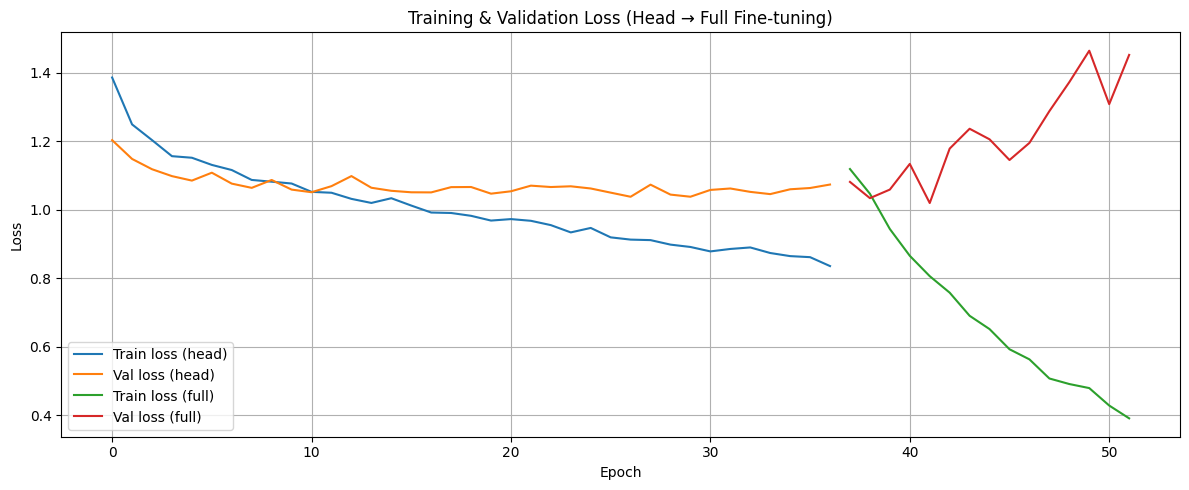

In [ ]:
try:
  study.best_params
except:
  study = None
  #ignore?

if study is None:
  best_lr_head = 0.00035950484601540223
  best_lr_full = 2.271080330783799e-05
  best_batch_size = 8
else:
  best_lr_head = study.best_params["lr_head"]
  best_lr_full = study.best_params["lr_full"]
  best_batch_size = study.best_params["batch_size"]


train_loader = DataLoader(
    train_dataset,
    batch_size=best_batch_size,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=best_batch_size,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

model = ViTClassifierCLSPool(num_classes=11).to(device)
criterion = nn.CrossEntropyLoss()

freeze_backbone(model)

optimizer = torch.optim.AdamW(
      model.classifier.parameters(),
      lr=best_lr_head
)

model, history_head = train_model(
      model,
      train_loader,
      val_loader,
      criterion,
      optimizer,
      device,
      epochs=1000,
      patience=10,
      save_path=CHECKPOINT_DIR + '/' +"vit_2_stage1_best.pt"
)

# do retrain the second stage, because it failed the first time...
  # model = ViTClassifierCLSPool(num_classes=11).to(device)
  # criterion = nn.CrossEntropyLoss()

  # model.load_state_dict(
  #   torch.load("vit_2_stage2_best.pt", map_location=device))

  # checkpoint = torch.load("vit_2_stage2_best.pt", map_location=device)

  # model.load_state_dict(checkpoint["model_state"])
  # history = checkpoint["history"]

  # print("Resume from best epoch:", checkpoint["epoch"])
  # print("Resume from Best val loss:", checkpoint["best_val_loss"])


unfreeze_backbone(model)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=best_lr_full
)

model, history_full = train_model(
      model,
      train_loader,
      val_loader,
      criterion,
      optimizer,
      device,
      epochs=1000,
      patience=10,
      save_path=CHECKPOINT_DIR + '/' +"vit_2_stage2_best.pt"
)

import matplotlib.pyplot as plt

# Can't print because I didn't save history before.

plt.figure(figsize=(12, 5))

# Head stage
plt.plot(history_head["train_loss"], label="Train loss (head)")
plt.plot(history_head["val_loss"], label="Val loss (head)")

# Full stage
plt.plot(
    range(len(history_head["train_loss"]),
          len(history_head["train_loss"]) + len(history_full["train_loss"])),
    history_full["train_loss"],
    label="Train loss (full)"
)
plt.plot(
    range(len(history_head["val_loss"]),
          len(history_head["val_loss"]) + len(history_full["val_loss"])),
    history_full["val_loss"],
    label="Val loss (full)"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss (Head → Full Fine-tuning)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



### 4. ViT with deep head


### 4.1 model function definitions:

In [ ]:
import torch
import torch.nn as nn
from torchvision import models
import copy
from sklearn.metrics import accuracy_score

class ViTClassifierDeepHead(nn.Module):
    """
    Standard ViT using CLS token only
    Deeper MLP classification head
    """
    def __init__(self, num_classes=11, dropout=0.5):
        super().__init__()

        self.vit = models.vit_b_16(
            weights=models.ViT_B_16_Weights.IMAGENET1K_V1
        )

        hidden_dim = self.vit.hidden_dim

        # Remove original head
        self.vit.heads = nn.Identity()

        # Simple, deeper classifier head
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

# For medium head depth experiment:
#         self.classifier = nn.Sequential(
#     nn.LayerNorm(hidden_dim),
#     nn.Linear(hidden_dim, 256),
#     nn.GELU(),
#     nn.Dropout(dropout),
#     nn.Linear(256, num_classes)
# )

    def forward(self, x):
        # Let torchvision ViT handle everything
        features = self.vit(x)  # CLS token output
        return self.classifier(features)

# Freeze / Unfreeze helpers
def freeze_backbone(model):
    for param in model.vit.parameters():
        param.requires_grad = False

    for param in model.classifier.parameters():
        param.requires_grad = True

def unfreeze_backbone(model):
    for param in model.parameters():
        param.requires_grad = True

# Training / Evaluation
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    preds, targets = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        preds.append(outputs.argmax(dim=1).cpu())
        targets.append(labels.cpu())
    preds = torch.cat(preds)
    targets = torch.cat(targets)
    acc = accuracy_score(targets, preds)
    return total_loss / len(loader.dataset), acc

def train_model(model, train_loader, val_loader, criterion, optimizer, device,
                epochs=50, patience=10, save_path="best_model.pt"):
    best_val_loss = float("inf")
    patience_counter = 0
    best_weights = copy.deepcopy(model.state_dict())

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(1, epochs+1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        # store values
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch [{epoch}/{epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            # if save_path is not None:
            #   torch.save(model.state_dict(), save_path)
            best_checkpoint = {
                "epoch": epoch,
                "model_state": copy.deepcopy(model.state_dict()),
                "optimizer_state": optimizer.state_dict(),
                "history": copy.deepcopy(history),
                "best_val_loss": best_val_loss
            }

            if save_path is not None:
                if CHECKPOINT_DIR not in save_path:
                  if '/' not in save_path:
                    save_path = CHECKPOINT_DIR + '/' + save_path
                  else:
                    save_path = CHECKPOINT_DIR + save_path

                torch.save(best_checkpoint, save_path)
                print("Best model + history saved")

            patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered")
            break

    model.load_state_dict(best_weights)
    return model, history

### 4.2 Find best parameters with Optuna

In [ ]:
# install optuna if not before:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 10.3 MB/s eta 0:00:00


In [ ]:
import optuna
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

def objective(trial):
    # Hyperparameters
    lr_head = trial.suggest_float("lr_head", 1e-4, 1e-3, log=True)
    lr_full = trial.suggest_float("lr_full", 1e-5, 1e-4, log=True)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])

    # Rebuild dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    # Model
    model = ViTClassifierDeepHead(num_classes=11).to(device)
    criterion = nn.CrossEntropyLoss()

    # Stage 1: classifier only
    freeze_backbone(model)

    optimizer = torch.optim.AdamW(
        model.classifier.parameters(),
        lr=lr_head
    )

    train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        device,
        epochs=10,
        patience=3,
        save_path=None
    )

    # Stage 2: full fine-tuning
    unfreeze_backbone(model)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr_full
    )

    train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        device,
        epochs=10,
        patience=3,
        save_path=None
    )

    _, val_acc = evaluate(model, val_loader, criterion, device)
    return val_acc


if True:
  study = optuna.create_study(direction="maximize")
  study.optimize(objective, n_trials=5)

  print("Best validation accuracy:", study.best_value)
  print("Best hyperparameters:", study.best_params)

[I 2026-02-28 14:32:22,246] A new study created in memory with name: no-name-57086898-faaa-4ce3-9c03-979fb887f667


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 193MB/s]


Epoch [1/10] | Train Loss: 1.4827 | Val Loss: 1.2175 | Val Acc: 0.5916
Epoch [2/10] | Train Loss: 1.2762 | Val Loss: 1.1623 | Val Acc: 0.6126
Epoch [3/10] | Train Loss: 1.2075 | Val Loss: 1.1227 | Val Acc: 0.6240
Epoch [4/10] | Train Loss: 1.1727 | Val Loss: 1.1010 | Val Acc: 0.6355
Epoch [5/10] | Train Loss: 1.1600 | Val Loss: 1.0950 | Val Acc: 0.6336
Epoch [6/10] | Train Loss: 1.1433 | Val Loss: 1.0945 | Val Acc: 0.6260
Epoch [7/10] | Train Loss: 1.1130 | Val Loss: 1.0989 | Val Acc: 0.6240
Epoch [8/10] | Train Loss: 1.0954 | Val Loss: 1.0746 | Val Acc: 0.6298
Epoch [9/10] | Train Loss: 1.0934 | Val Loss: 1.0686 | Val Acc: 0.6240
Epoch [10/10] | Train Loss: 1.0662 | Val Loss: 1.0591 | Val Acc: 0.6240
Epoch [1/10] | Train Loss: 1.2622 | Val Loss: 1.1338 | Val Acc: 0.6355
Epoch [2/10] | Train Loss: 1.1346 | Val Loss: 1.0626 | Val Acc: 0.6374
Epoch [3/10] | Train Loss: 1.0725 | Val Loss: 1.1113 | Val Acc: 0.6469
Epoch [4/10] | Train Loss: 1.0186 | Val Loss: 1.2292 | Val Acc: 0.6050
Epoch

[I 2026-02-28 15:37:14,972] Trial 0 finished with value: 0.6412213740458015 and parameters: {'lr_head': 0.00018238139329812078, 'lr_full': 8.182721732477618e-05, 'batch_size': 16}. Best is trial 0 with value: 0.6412213740458015.


...

Epoch [1/10] | Train Loss: 1.4559 | Val Loss: 1.2009 | Val Acc: 0.5878
Epoch [2/10] | Train Loss: 1.2661 | Val Loss: 1.1705 | Val Acc: 0.6011
Epoch [3/10] | Train Loss: 1.2144 | Val Loss: 1.1323 | Val Acc: 0.6069
Epoch [4/10] | Train Loss: 1.1707 | Val Loss: 1.1148 | Val Acc: 0.6164
Epoch [5/10] | Train Loss: 1.1640 | Val Loss: 1.0914 | Val Acc: 0.6221
Epoch [6/10] | Train Loss: 1.1348 | Val Loss: 1.0848 | Val Acc: 0.6260
Epoch [7/10] | Train Loss: 1.1210 | Val Loss: 1.0771 | Val Acc: 0.6279
Epoch [8/10] | Train Loss: 1.0977 | Val Loss: 1.1153 | Val Acc: 0.6221
Epoch [9/10] | Train Loss: 1.0901 | Val Loss: 1.0586 | Val Acc: 0.6336
Epoch [10/10] | Train Loss: 1.0693 | Val Loss: 1.0499 | Val Acc: 0.6469
Epoch [1/10] | Train Loss: 1.0864 | Val Loss: 1.0503 | Val Acc: 0.6374
Epoch [2/10] | Train Loss: 0.9708 | Val Loss: 1.0117 | Val Acc: 0.6489
Epoch [3/10] | Train Loss: 0.8954 | Val Loss: 1.0248 | Val Acc: 0.6508
Epoch [4/10] | Train Loss: 0.8100 | Val Loss: 0.9862 | Val Acc: 0.6698
Epoch

[I 2026-02-28 17:19:01,355] Trial 3 finished with value: 0.6698473282442748 and parameters: {'lr_head': 0.00017688424125858354, 'lr_full': 2.1138072364282908e-05, 'batch_size': 16}. Best is trial 3 with value: 0.6698473282442748.


Epoch [1/10] | Train Loss: 1.4653 | Val Loss: 1.2064 | Val Acc: 0.5878
Epoch [2/10] | Train Loss: 1.2684 | Val Loss: 1.1603 | Val Acc: 0.6069
Epoch [3/10] | Train Loss: 1.1945 | Val Loss: 1.1292 | Val Acc: 0.6069
Epoch [4/10] | Train Loss: 1.1709 | Val Loss: 1.1057 | Val Acc: 0.6164
Epoch [5/10] | Train Loss: 1.1567 | Val Loss: 1.1025 | Val Acc: 0.6202
Epoch [6/10] | Train Loss: 1.1277 | Val Loss: 1.0823 | Val Acc: 0.6279
Epoch [7/10] | Train Loss: 1.1007 | Val Loss: 1.0869 | Val Acc: 0.6298
Epoch [8/10] | Train Loss: 1.0962 | Val Loss: 1.0560 | Val Acc: 0.6412
Epoch [9/10] | Train Loss: 1.0919 | Val Loss: 1.0493 | Val Acc: 0.6317
Epoch [10/10] | Train Loss: 1.0667 | Val Loss: 1.0623 | Val Acc: 0.6298
Epoch [1/10] | Train Loss: 1.2136 | Val Loss: 1.1453 | Val Acc: 0.6145
Epoch [2/10] | Train Loss: 1.0766 | Val Loss: 1.1584 | Val Acc: 0.6202
Epoch [3/10] | Train Loss: 1.0404 | Val Loss: 1.0854 | Val Acc: 0.6336
Epoch [4/10] | Train Loss: 0.9575 | Val Loss: 1.0439 | Val Acc: 0.6584
Epoch

[I 2026-02-28 17:50:12,953] Trial 4 finished with value: 0.6526717557251909 and parameters: {'lr_head': 0.00037180178905375685, 'lr_full': 8.19049846148004e-05, 'batch_size': 32}. Best is trial 3 with value: 0.6698473282442748.


Best validation accuracy: 0.6698473282442748
Best hyperparameters: {'lr_head': 0.00017688424125858354, 'lr_full': 2.1138072364282908e-05, 'batch_size': 16}


Best parameters:
Best validation accuracy: 0.6698473282442748
Best hyperparameters: {'lr_head': 0.00017688424125858354, 'lr_full': 2.1138072364282908e-05, 'batch_size': 16}


### 4.3 Train model with the best optuna parameters

Epoch [1/1000] | Train Loss: 1.4822 | Val Loss: 1.2195 | Val Acc: 0.5878
Best model + history saved
Epoch [2/1000] | Train Loss: 1.2621 | Val Loss: 1.1461 | Val Acc: 0.6069
Best model + history saved
Epoch [3/1000] | Train Loss: 1.2154 | Val Loss: 1.1524 | Val Acc: 0.6088
Epoch [4/1000] | Train Loss: 1.1848 | Val Loss: 1.1136 | Val Acc: 0.6183
Best model + history saved
Epoch [5/1000] | Train Loss: 1.1653 | Val Loss: 1.1216 | Val Acc: 0.6183
Epoch [6/1000] | Train Loss: 1.1488 | Val Loss: 1.0843 | Val Acc: 0.6260
Best model + history saved
Epoch [7/1000] | Train Loss: 1.1048 | Val Loss: 1.0930 | Val Acc: 0.6355
Epoch [8/1000] | Train Loss: 1.1078 | Val Loss: 1.0689 | Val Acc: 0.6355
Best model + history saved
Epoch [9/1000] | Train Loss: 1.0827 | Val Loss: 1.0832 | Val Acc: 0.6508
Epoch [10/1000] | Train Loss: 1.0664 | Val Loss: 1.0669 | Val Acc: 0.6374
Best model + history saved
Epoch [11/1000] | Train Loss: 1.0566 | Val Loss: 1.0565 | Val Acc: 0.6412
Best model + history saved
Epoch 

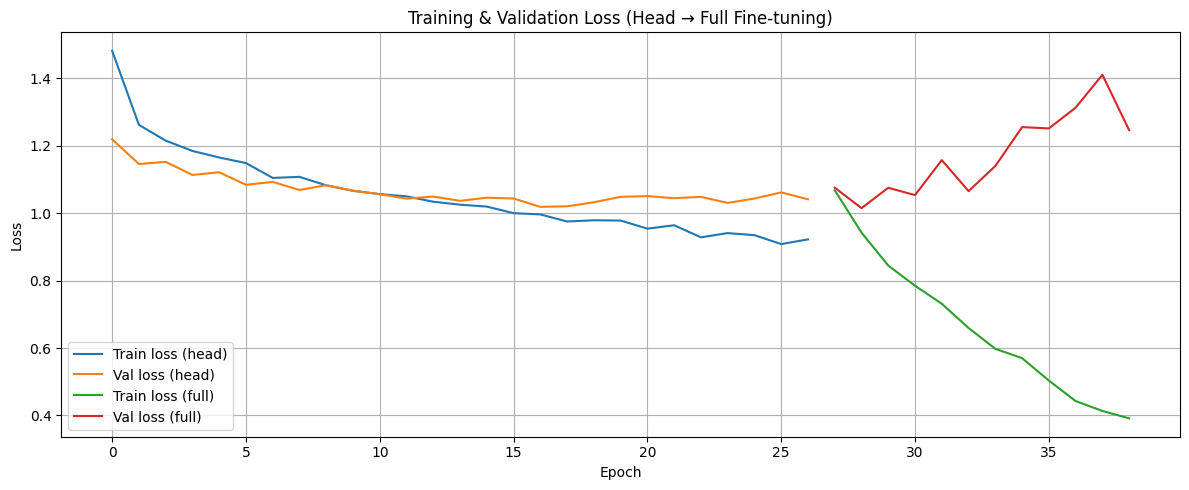

In [ ]:
try:
  study.best_params
except:
  study = None
  #ignore?

if study is None:
  best_lr_head = 0.00017688424125858354
  best_lr_full = 2.1138072364282908e-05
  best_batch_size = 16
else:
  best_lr_head = study.best_params["lr_head"]
  best_lr_full = study.best_params["lr_full"]
  best_batch_size = study.best_params["batch_size"]


train_loader = DataLoader(
    train_dataset,
    batch_size=best_batch_size,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=best_batch_size,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

model = ViTClassifierDeepHead(num_classes=11).to(device)
criterion = nn.CrossEntropyLoss()

freeze_backbone(model)

optimizer = torch.optim.AdamW(
      model.classifier.parameters(),
      lr=best_lr_head
)

model, history_head = train_model(
      model,
      train_loader,
      val_loader,
      criterion,
      optimizer,
      device,
      epochs=1000,
      patience=10,
      save_path=CHECKPOINT_DIR + '/' +"vit_3_stage1_best.pt"
)

# do retrain the second stage, because it failed the first time...
  # model = ViTClassifierCLSPool(num_classes=11).to(device)
  # criterion = nn.CrossEntropyLoss()

  # model.load_state_dict(
  #   torch.load("vit_2_stage2_best.pt", map_location=device))

  # checkpoint = torch.load("vit_2_stage2_best.pt", map_location=device)

  # model.load_state_dict(checkpoint["model_state"])
  # history = checkpoint["history"]

  # print("Resume from best epoch:", checkpoint["epoch"])
  # print("Resume from Best val loss:", checkpoint["best_val_loss"])


unfreeze_backbone(model)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=best_lr_full
)

model, history_full = train_model(
      model,
      train_loader,
      val_loader,
      criterion,
      optimizer,
      device,
      epochs=1000,
      patience=10,
      save_path=CHECKPOINT_DIR + '/' +"vit_3_stage2_best.pt"
)

import matplotlib.pyplot as plt

# Can't print because I didn't save history before.

plt.figure(figsize=(12, 5))

# Head stage
plt.plot(history_head["train_loss"], label="Train loss (head)")
plt.plot(history_head["val_loss"], label="Val loss (head)")

# Full stage
plt.plot(
    range(len(history_head["train_loss"]),
          len(history_head["train_loss"]) + len(history_full["train_loss"])),
    history_full["train_loss"],
    label="Train loss (full)"
)
plt.plot(
    range(len(history_head["val_loss"]),
          len(history_head["val_loss"]) + len(history_full["val_loss"])),
    history_full["val_loss"],
    label="Val loss (full)"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss (Head → Full Fine-tuning)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



Hopefully it's oK :D:D:D

## 5. ResNet 18 first try


In [ ]:
from ResNet18_1_definitions import *

In [ ]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 13.5 MB/s eta 0:00:00


In [ ]:
import optuna
import torch.nn as nn

def objective(trial):
    lr_head = trial.suggest_float("lr_head", 1e-4, 1e-3)
    lr_full = trial.suggest_float("lr_full", 1e-5, 1e-4)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])

    # Rebuild dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    model = ResNet18Classifier(num_classes=11).to(device)
    criterion = nn.CrossEntropyLoss()

    # STAGE 1: HEAD ONLY
    freeze_backbone(model)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr_head
    )

    train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        device,
        epochs=8,   # short for Optuna
        patience=3,
        save_path=None
    )

    # STAGE 2: FULL MODEL
    unfreeze_backbone(model)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr_full
    )

    train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        device,
        epochs=8,   # also short
        patience=3,
        save_path=None
    )

    # Final evaluation
    _, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    return val_acc

############# Run the study:
if True:
  study = optuna.create_study(
      direction="maximize"
  )

  study.optimize(
      objective,
      n_trials=8,
      timeout=None          # optional
  )

  print("Best validation accuracy:", study.best_value)
  print("Best hyperparameters:", study.best_params)

[I 2026-03-03 10:45:47,057] A new study created in memory with name: no-name-6048e81a-9871-4aef-ac12-876e0b4fe9ec


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 149MB/s]


Epoch [1/8] | Train Loss: 1.5447 | Val Loss: 1.2523 | Val Acc: 0.5897
Epoch [2/8] | Train Loss: 1.3124 | Val Loss: 1.2222 | Val Acc: 0.5840
Epoch [3/8] | Train Loss: 1.2841 | Val Loss: 1.1895 | Val Acc: 0.5878
Epoch [4/8] | Train Loss: 1.2680 | Val Loss: 1.1813 | Val Acc: 0.5954
Epoch [5/8] | Train Loss: 1.2390 | Val Loss: 1.1546 | Val Acc: 0.6069
Epoch [6/8] | Train Loss: 1.2199 | Val Loss: 1.1368 | Val Acc: 0.6126
Epoch [7/8] | Train Loss: 1.2266 | Val Loss: 1.1554 | Val Acc: 0.6107
Epoch [8/8] | Train Loss: 1.2121 | Val Loss: 1.1320 | Val Acc: 0.6011
Epoch [1/8] | Train Loss: 1.1952 | Val Loss: 1.1211 | Val Acc: 0.6145
Epoch [2/8] | Train Loss: 1.1096 | Val Loss: 1.0873 | Val Acc: 0.6336
Epoch [3/8] | Train Loss: 1.0384 | Val Loss: 1.0452 | Val Acc: 0.6336
Epoch [4/8] | Train Loss: 0.9887 | Val Loss: 1.0789 | Val Acc: 0.6336
Epoch [5/8] | Train Loss: 0.9494 | Val Loss: 1.0398 | Val Acc: 0.6355
Epoch [6/8] | Train Loss: 0.8822 | Val Loss: 1.0673 | Val Acc: 0.6431
Epoch [7/8] | Train 

[I 2026-03-03 11:04:42,655] Trial 0 finished with value: 0.6354961832061069 and parameters: {'lr_head': 0.000599834592616876, 'lr_full': 5.270617979888602e-05, 'batch_size': 16}. Best is trial 0 with value: 0.6354961832061069.


...

Epoch [1/8] | Train Loss: 1.6112 | Val Loss: 1.2592 | Val Acc: 0.5897
Epoch [2/8] | Train Loss: 1.3125 | Val Loss: 1.2120 | Val Acc: 0.5992
Epoch [3/8] | Train Loss: 1.2619 | Val Loss: 1.1815 | Val Acc: 0.5840
Epoch [4/8] | Train Loss: 1.2446 | Val Loss: 1.1781 | Val Acc: 0.5897
Epoch [5/8] | Train Loss: 1.2201 | Val Loss: 1.1679 | Val Acc: 0.5935
Epoch [6/8] | Train Loss: 1.2132 | Val Loss: 1.1668 | Val Acc: 0.5954
Epoch [7/8] | Train Loss: 1.1947 | Val Loss: 1.1445 | Val Acc: 0.6031
Epoch [8/8] | Train Loss: 1.1764 | Val Loss: 1.1414 | Val Acc: 0.5992
Epoch [1/8] | Train Loss: 1.1591 | Val Loss: 1.0925 | Val Acc: 0.6317
Epoch [2/8] | Train Loss: 1.0522 | Val Loss: 1.0620 | Val Acc: 0.6469
Epoch [3/8] | Train Loss: 0.9655 | Val Loss: 1.0398 | Val Acc: 0.6508
Epoch [4/8] | Train Loss: 0.9154 | Val Loss: 1.0318 | Val Acc: 0.6412
Epoch [5/8] | Train Loss: 0.8416 | Val Loss: 1.0262 | Val Acc: 0.6584
Epoch [6/8] | Train Loss: 0.7789 | Val Loss: 1.1094 | Val Acc: 0.6393
Epoch [7/8] | Train 

[I 2026-03-03 11:44:31,066] Trial 6 finished with value: 0.6583969465648855 and parameters: {'lr_head': 0.0006287701638032997, 'lr_full': 9.140398449542602e-05, 'batch_size': 32}. Best is trial 6 with value: 0.6583969465648855.


Epoch [1/8] | Train Loss: 1.5631 | Val Loss: 1.2321 | Val Acc: 0.5878
Epoch [2/8] | Train Loss: 1.2929 | Val Loss: 1.2192 | Val Acc: 0.5763
Epoch [3/8] | Train Loss: 1.2438 | Val Loss: 1.1709 | Val Acc: 0.5897
Epoch [4/8] | Train Loss: 1.2219 | Val Loss: 1.1435 | Val Acc: 0.5935
Epoch [5/8] | Train Loss: 1.2169 | Val Loss: 1.1513 | Val Acc: 0.5992
Epoch [6/8] | Train Loss: 1.2198 | Val Loss: 1.1368 | Val Acc: 0.5992
Epoch [7/8] | Train Loss: 1.1780 | Val Loss: 1.1515 | Val Acc: 0.6050
Epoch [8/8] | Train Loss: 1.1692 | Val Loss: 1.1456 | Val Acc: 0.5935
Epoch [1/8] | Train Loss: 1.1525 | Val Loss: 1.0802 | Val Acc: 0.6279
Epoch [2/8] | Train Loss: 1.0493 | Val Loss: 1.0549 | Val Acc: 0.6317
Epoch [3/8] | Train Loss: 0.9860 | Val Loss: 1.0378 | Val Acc: 0.6489
Epoch [4/8] | Train Loss: 0.9327 | Val Loss: 1.0576 | Val Acc: 0.6450
Epoch [5/8] | Train Loss: 0.8794 | Val Loss: 1.0460 | Val Acc: 0.6374
Epoch [6/8] | Train Loss: 0.8216 | Val Loss: 1.0403 | Val Acc: 0.6603
Early stopping trigg

[I 2026-03-03 11:49:59,840] Trial 7 finished with value: 0.648854961832061 and parameters: {'lr_head': 0.0009768049919635416, 'lr_full': 4.925832239072087e-05, 'batch_size': 32}. Best is trial 6 with value: 0.6583969465648855.


Best validation accuracy: 0.6583969465648855
Best hyperparameters: {'lr_head': 0.0006287701638032997, 'lr_full': 9.140398449542602e-05, 'batch_size': 32}


Best validation accuracy: 0.6583969465648855
Best hyperparameters: {'lr_head': 0.0006287701638032997, 'lr_full': 9.140398449542602e-05, 'batch_size': 32}

Best validation accuracy: 0.6583969465648855
Best hyperparameters: {'lr_head': 0.0006287701638032997, 'lr_full': 9.140398449542602e-05, 'batch_size': 32}




Epoch [1/1000] | Train Loss: 1.5753 | Val Loss: 1.2784 | Val Acc: 0.5802
Best model + history saved
Epoch [2/1000] | Train Loss: 1.3078 | Val Loss: 1.2109 | Val Acc: 0.5878
Best model + history saved
Epoch [3/1000] | Train Loss: 1.2729 | Val Loss: 1.1842 | Val Acc: 0.5954
Best model + history saved
Epoch [4/1000] | Train Loss: 1.2512 | Val Loss: 1.1668 | Val Acc: 0.5954
Best model + history saved
Epoch [5/1000] | Train Loss: 1.2291 | Val Loss: 1.1465 | Val Acc: 0.6050
Best model + history saved
Epoch [6/1000] | Train Loss: 1.2098 | Val Loss: 1.1485 | Val Acc: 0.6050
Epoch [7/1000] | Train Loss: 1.1819 | Val Loss: 1.1521 | Val Acc: 0.6050
Epoch [8/1000] | Train Loss: 1.1736 | Val Loss: 1.1379 | Val Acc: 0.5992
Best model + history saved
Epoch [9/1000] | Train Loss: 1.1761 | Val Loss: 1.1239 | Val Acc: 0.6050
Best model + history saved
Epoch [10/1000] | Train Loss: 1.1675 | Val Loss: 1.1195 | Val Acc: 0.6011
Best model + history saved
Epoch [11/1000] | Train Loss: 1.1620 | Val Loss: 1.13

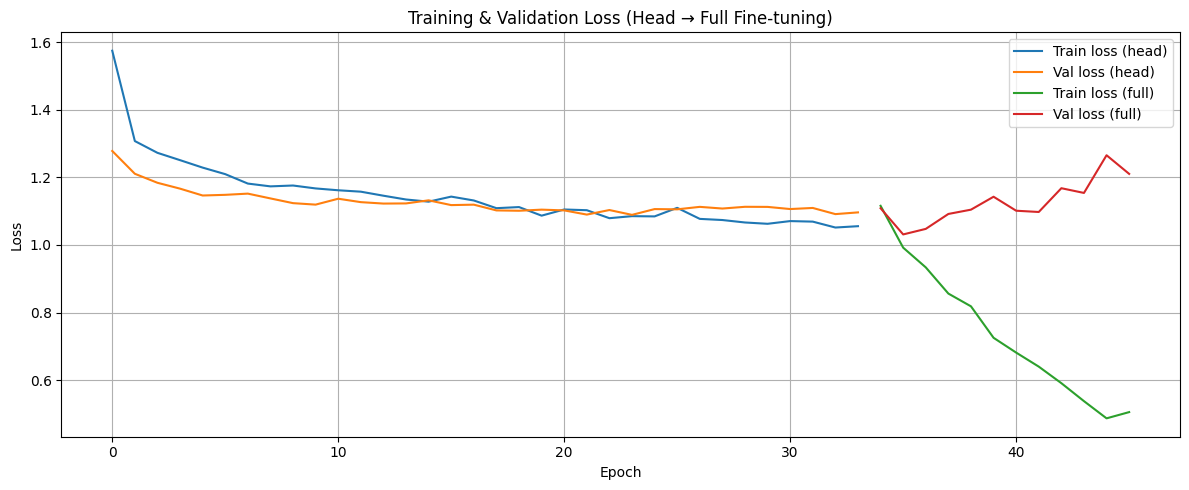

In [ ]:
try:
  study.best_params
except:
  study = None
  #ignore?

if study is None:
  best_lr_head = -7
  best_lr_full = -7
  best_batch_size = -6
else:
  best_lr_head = study.best_params["lr_head"]
  best_lr_full = study.best_params["lr_full"]
  best_batch_size = study.best_params["batch_size"]


train_loader = DataLoader(
    train_dataset,
    batch_size=best_batch_size,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=best_batch_size,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

model = ResNet18Classifier(num_classes=11).to(device)
criterion = nn.CrossEntropyLoss()

freeze_backbone(model)

optimizer = torch.optim.AdamW(
      model.head.parameters(),
      lr=best_lr_head
)

model, history_head = train_model(
      model,
      train_loader,
      val_loader,
      criterion,
      optimizer,
      device,
      epochs=1000,
      patience=10,
      save_path=CHECKPOINT_DIR + '/' +"Resnet_2_stage1_best.pt"
)

# do retrain the second stage, because it failed the first time...
  # model = ViTClassifierCLSPool(num_classes=11).to(device)
  # criterion = nn.CrossEntropyLoss()

  # model.load_state_dict(
  #   torch.load("vit_2_stage2_best.pt", map_location=device))

  # checkpoint = torch.load("vit_2_stage2_best.pt", map_location=device)

  # model.load_state_dict(checkpoint["model_state"])
  # history = checkpoint["history"]

  # print("Resume from best epoch:", checkpoint["epoch"])
  # print("Resume from Best val loss:", checkpoint["best_val_loss"])


unfreeze_backbone(model)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=best_lr_full
)

model, history_full = train_model(
      model,
      train_loader,
      val_loader,
      criterion,
      optimizer,
      device,
      epochs=1000,
      patience=10,
      save_path=CHECKPOINT_DIR + '/' +"Resnet_2_stage2_best.pt"
)

import matplotlib.pyplot as plt

# Can't print because I didn't save history before.

plt.figure(figsize=(12, 5))

# Head stage
plt.plot(history_head["train_loss"], label="Train loss (head)")
plt.plot(history_head["val_loss"], label="Val loss (head)")

# Full stage
plt.plot(
    range(len(history_head["train_loss"]),
          len(history_head["train_loss"]) + len(history_full["train_loss"])),
    history_full["train_loss"],
    label="Train loss (full)"
)
plt.plot(
    range(len(history_head["val_loss"]),
          len(history_head["val_loss"]) + len(history_full["val_loss"])),
    history_full["val_loss"],
    label="Val loss (full)"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss (Head → Full Fine-tuning)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()